In [2]:
import tensorflow as tf 
from keras.layers import Rescaling
from tensorflow.keras.utils import image_dataset_from_directory 
from tensorflow.keras import layers , models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix , classification_report
from tensorflow.keras.models  import load_model
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
import os


In [2]:
train_dataset = image_dataset_from_directory(".\dataset\cassava", image_size=(224, 224), batch_size=32)

Found 21397 files belonging to 5 classes.


In [3]:
train_dataset =image_dataset_from_directory(".\dataset\cassava",validation_split=0.2, subset="training", seed=42, image_size=(224 , 224) , batch_size=32 , label_mode="categorical")
validation_dataset =image_dataset_from_directory(".\dataset\cassava",validation_split=0.2, subset="validation", seed=42, image_size=(224 , 224) , batch_size=32 , label_mode="categorical")
class_names = train_dataset.class_names
print("class order:" , class_names)

Found 21397 files belonging to 5 classes.
Using 17118 files for training.
Found 21397 files belonging to 5 classes.
Using 4279 files for validation.
class order: ['Cassava___bacterial_blight', 'Cassava___brown_streak_disease', 'Cassava___green_mottle', 'Cassava___healthy', 'Cassava___mosaic_disease']


In [4]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [5]:
preprocess_layer = layers.Lambda(preprocess_input)

In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomContrast(0.1)
])



In [7]:
num_classes = len(class_names)
base_model = tf.keras.applications.MobileNetV2(
    input_shape =(224,224, 3),
    include_top = False,
    weights = "imagenet"
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(224 , 224 , 3))
x = data_augmentation(inputs)
x = preprocess_layer(x)
x = base_model(x , training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes , activation="softmax")(x)

model = tf.keras.Model(inputs , outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
model.compile(
    optimizer= tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [3]:


model = load_model(
    "cassava_model.keras",
    custom_objects={
        "preprocess_input": preprocess_input
    }
)

print("Model loaded successfully!")


Model loaded successfully!


In [10]:
base_model = model.get_layer("mobilenetv2_1.00_224")
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 30
for layer  in base_model.layers[:fine_tune_at]:
    layer.trainable = False

In [11]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
model_fine_tune = load_model(
    "cassava_model_finetune.keras",
    custom_objects={
        "preprocess_input": preprocess_input
    }
)

print("Model loaded successfully!")

Model loaded successfully!


In [13]:
y_true = []
y_predict = []

for images , labels in validation_dataset:
    pred = model.predict(images , verbose=0)
    y_true.extend(np.argmax(labels.numpy() , axis=1))
    y_predict.extend(np.argmax(pred , axis=1))

print(classification_report(y_true,y_predict , target_names=class_names))

                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.47      0.38      0.42       216
Cassava___brown_streak_disease       0.55      0.41      0.47       431
        Cassava___green_mottle       0.67      0.21      0.32       491
             Cassava___healthy       0.31      0.84      0.45       495
      Cassava___mosaic_disease       0.90      0.77      0.83      2646

                      accuracy                           0.66      4279
                     macro avg       0.58      0.52      0.50      4279
                  weighted avg       0.75      0.66      0.67      4279



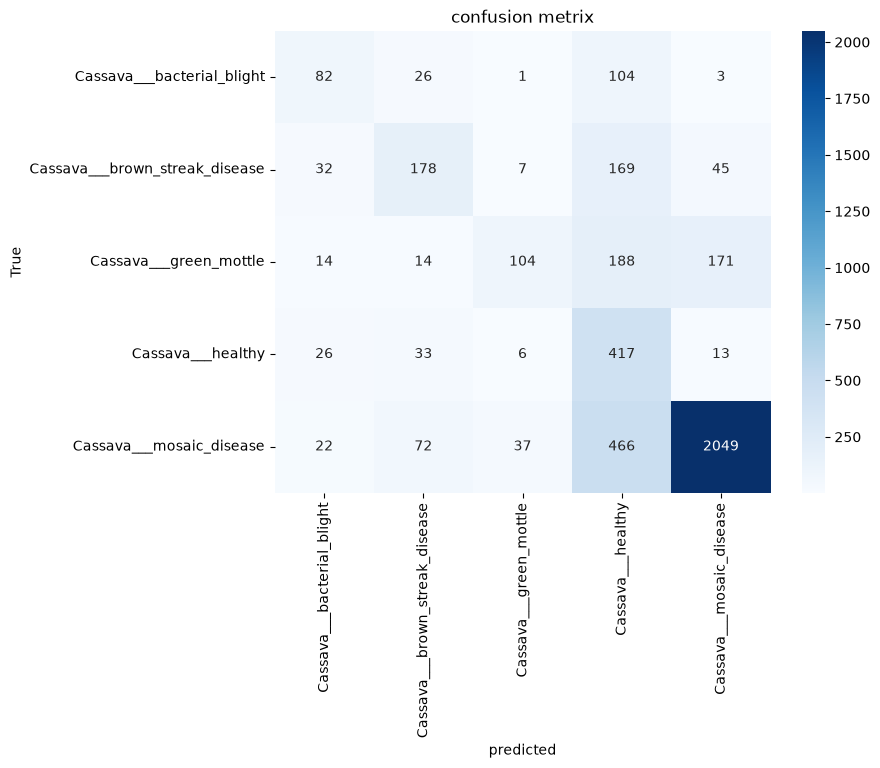

In [14]:
cm = confusion_matrix(y_true , y_predict)
plt.figure(figsize=(8,6))
sns.heatmap(cm , annot=True , fmt="d" , xticklabels=class_names , yticklabels=class_names , cmap="Blues")
plt.xlabel("predicted")
plt.ylabel("True")
plt.title("confusion metrix")
plt.show()    



In [15]:
train_dataset = tf.keras.utils.image_dataset_from_directory(".\dataset\cassava",validation_split=0.2, subset="training", seed=123, image_size=(224 , 224) , batch_size=32 , label_mode="categorical" , shuffle=True)
train_dataset = tf.keras.utils.image_dataset_from_directory(".\dataset\cassava",validation_split=0.2, subset="validation", seed=123, image_size=(224 , 224) , batch_size=32 , label_mode="categorical" , shuffle=False)

Found 21397 files belonging to 5 classes.
Using 17118 files for training.
Found 21397 files belonging to 5 classes.
Using 4279 files for validation.


In [16]:
y_train_labels = np.concatenate([np.argmax(y.numpy() , axis=1) for x , y in train_dataset])
weights = compute_class_weight(class_weight="balanced" , classes=np.unique(y_train_labels), y=y_train_labels)
class_weight_dict = dict(enumerate(weights))



In [17]:
print("class names:")
print (train_dataset.class_names)
print("\nclass weighr :")
print(class_weight_dict)

class names:
['Cassava___bacterial_blight', 'Cassava___brown_streak_disease', 'Cassava___green_mottle', 'Cassava___healthy', 'Cassava___mosaic_disease']

class weighr :
{0: np.float64(1.0)}


In [18]:
print(len(class_weight_dict))
print(all(isinstance(k, int) for k in class_weight_dict.keys()))
print(all(v > 0 for v in class_weight_dict.values()))

1
True
True


In [19]:
y_train_labels = np.concatenate([
    labels.numpy()
    for images, labels in train_dataset
])

print("Unique labels:", np.unique(y_train_labels))
print("Number of classes:", len(np.unique(y_train_labels)))

Unique labels: [0. 1.]
Number of classes: 2


In [20]:
print("Class names:")
print(class_names)

print("\nUnique labels:")
print(np.unique(y_train_labels))

print("\nNumber of classes:")
print(len(np.unique(y_train_labels)))

Class names:
['Cassava___bacterial_blight', 'Cassava___brown_streak_disease', 'Cassava___green_mottle', 'Cassava___healthy', 'Cassava___mosaic_disease']

Unique labels:
[0. 1.]

Number of classes:
2


In [21]:
for images, labels in train_dataset.take(1):
    print("Labels shape:", labels.shape)
    print("Sample label:", labels[0].numpy())

Labels shape: (32, 5)
Sample label: [0. 0. 0. 0. 1.]


In [13]:
train_dataset = image_dataset_from_directory(
    "dataset/cassava",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224,224),
    batch_size=16,
    label_mode="categorical"
)
validation_dataset = image_dataset_from_directory(
    "dataset/cassava",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224,224),
    batch_size=16,
    label_mode="categorical"
)
class_names = train_dataset.class_names
print(class_names)

Found 21397 files belonging to 5 classes.
Using 17118 files for training.
Found 21397 files belonging to 5 classes.
Using 4279 files for validation.
['Cassava___bacterial_blight', 'Cassava___brown_streak_disease', 'Cassava___green_mottle', 'Cassava___healthy', 'Cassava___mosaic_disease']


In [23]:


y_train_labels = np.concatenate([
    np.argmax(labels.numpy(), axis=1) for images, labels in train_dataset
])

print("Unique labels:", np.unique(y_train_labels))
print("Number of classes:", len(np.unique(y_train_labels)))


Unique labels: [0 1 2 3 4]
Number of classes: 5


In [24]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weight_dict = dict(enumerate(weights))
print(class_weight_dict)

{0: np.float64(3.930654420206659), 1: np.float64(1.9474402730375426), 2: np.float64(1.8066490765171503), 3: np.float64(1.6443804034582132), 4: np.float64(0.3256849315068493)}


In [ ]:
history = model.fit(
    train_dataset , 
    validation_data=validation_dataset , 
    epochs=10 , 
    class_weight=class_weight_dict,
    shuffle=False,
    verbose=1
    )



Epoch 1/10
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 483s 445ms/step - accuracy: 0.5078 - loss: 1.4078 - val_accuracy: 0.5842 - val_loss: 1.1506
Epoch 2/10
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 495s 463ms/step - accuracy: 0.5768 - loss: 1.1771 - val_accuracy: 0.5866 - val_loss: 1.1138
Epoch 3/10
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 490s 458ms/step - accuracy: 0.6093 - loss: 1.0875 - val_accuracy: 0.5871 - val_loss: 1.1095
Epoch 4/10
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 483s 451ms/step - accuracy: 0.6265 - loss: 1.0355 - val_accuracy: 0.5611 - val_loss: 1.1576
Epoch 5/10
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 489s 457ms/step - accuracy: 0.6434 - loss: 0.9881 - val_accuracy: 0.5712 - val_loss: 1.1425
Epoch 6/10
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 507s 474ms/step - accuracy: 0.6533 - loss: 0.9674 - val_accuracy: 0.5672 - val_loss: 1.1674
Epoch 7/10
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 511s 478ms/step - accuracy: 0.6653 - loss: 0.9274 - val_accuracy: 0.5667 - val_loss: 1.1859
Epoch 8/10
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 944s 883ms/step - ac

In [9]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

model = tf.keras.models.load_model(
    "cassava_model_finetune.keras",
    custom_objects={"preprocess_input": preprocess_input}
)

print("Model loaded successfully!")


Model loaded successfully!


In [14]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_predict = []

for images, labels in validation_dataset:
    pred = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_predict.extend(np.argmax(pred, axis=1))

print(classification_report(y_true, y_predict, target_names=class_names))

                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.63      0.30      0.40       216
Cassava___brown_streak_disease       0.57      0.48      0.52       431
        Cassava___green_mottle       0.75      0.34      0.46       491
             Cassava___healthy       0.38      0.83      0.52       495
      Cassava___mosaic_disease       0.91      0.86      0.88      2646

                      accuracy                           0.73      4279
                     macro avg       0.65      0.56      0.56      4279
                  weighted avg       0.78      0.73      0.73      4279



In [1]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# --- Cassava ---
model = tf.keras.models.load_model(
    "./models/cassava_model_finetune.keras",
    custom_objects={"preprocess_input": preprocess_input}
)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # shrinks size further
tflite_model = converter.convert()
with open("cassava_model.tflite", "wb") as f:
    f.write(tflite_model)




INFO:tensorflow:Assets written to: C:\Users\ASUS\AppData\Local\Temp\tmp5ws9q009\assets


INFO:tensorflow:Assets written to: C:\Users\ASUS\AppData\Local\Temp\tmp5ws9q009\assets


Saved artifact at 'C:\Users\ASUS\AppData\Local\Temp\tmp5ws9q009'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_7')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  2032278568592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2032280176208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2032280176400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2032280175632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2032280175248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2032280175824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2032280177552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2032280177360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2032280176016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2032280178128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  20322